<center><img src='./Figs/cs-logo.png' width=200></center>



<h6><center></center></h6>

<h1>
<hr style=" border:none; height:3px;">
<center>eXplainable AI- Activity 1 : A small introduction</center>
<hr style=" border:none; height:3px;">
</h1>

The objective of this Lab is to make a first dive in the sea of explainable Artificial Intelligence. 
In this lab you will ask to :

+ Build, with your knowledge in Artificial Intelligence, some classification models to determine whether a person makes over 50K a year using the well-known [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/adult).
+ Try to explain your model with your own.
+ Test some existing tools in order to first familiarize with these tools but also to test if their use increase your knowledge and belief on your model and if the model thus gains in explainability.


# Requirements



You have to install using pip, the following modules.

* numpy
* pandas
* scipy
* scikit-learn
* matplotlib

And any module you want to use


# Data handling and simple data exploration

[Adult Data Set](https://archive.ics.uci.edu/ml/datasets/adult) is one of the most popular datasets which is a representative of the Finance domain. The dataset contains 32561 records of individuals including several features like occupation, age, marital status and so on (14 features). The prediction task is to determine whether a person makes over 50K a year.


With `pandas`, load and open the `adult.data` file as a dataframe and perform simple data exploration. The data is available [here](https://archive.ics.uci.edu/ml/machine-learning-databases/adult/).


Take the time to look at the different types of features [here](https://archive.ics.uci.edu/dataset/2/adult)

Load the data.

In [ ]:
# fetching didnt work so i just downloaded the data directly

In [1]:
import pandas as pd
import numpy as np

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

data = pd.read_csv('adult/adult.data', header=None, names=columns, na_values=' ?', skipinitialspace=True)

print('Columns:', columns)
print('Shape:', data.shape)

data.head()

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Simple data exploration

One of the principle of XAI and of responsible AI is to have a good knowledge on the input data. Propose and write some functions to have a better understanding of your input data.
Some questions are for instance :

+ The number of missing values 
+ The Class distribution in the dataset
+ Information on the correlation of the features
+ ...

=== Dataset shape ===
(32561, 15)

=== Missing values per column ===
Series([], dtype: int64)

=== ? values per column ===
  workclass: 1836
  occupation: 1843
  native-country: 583

=== Class distribution ===
income
<=50K    24720
>50K      7841
Name: count, dtype: int64



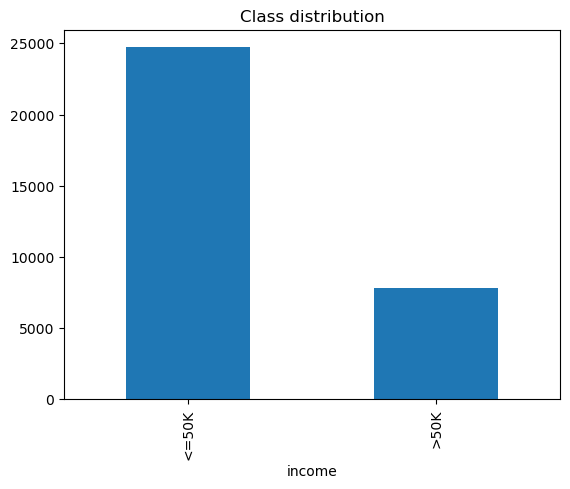

=== Data types ===
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

=== Descriptive statistics (numerical) ===
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      

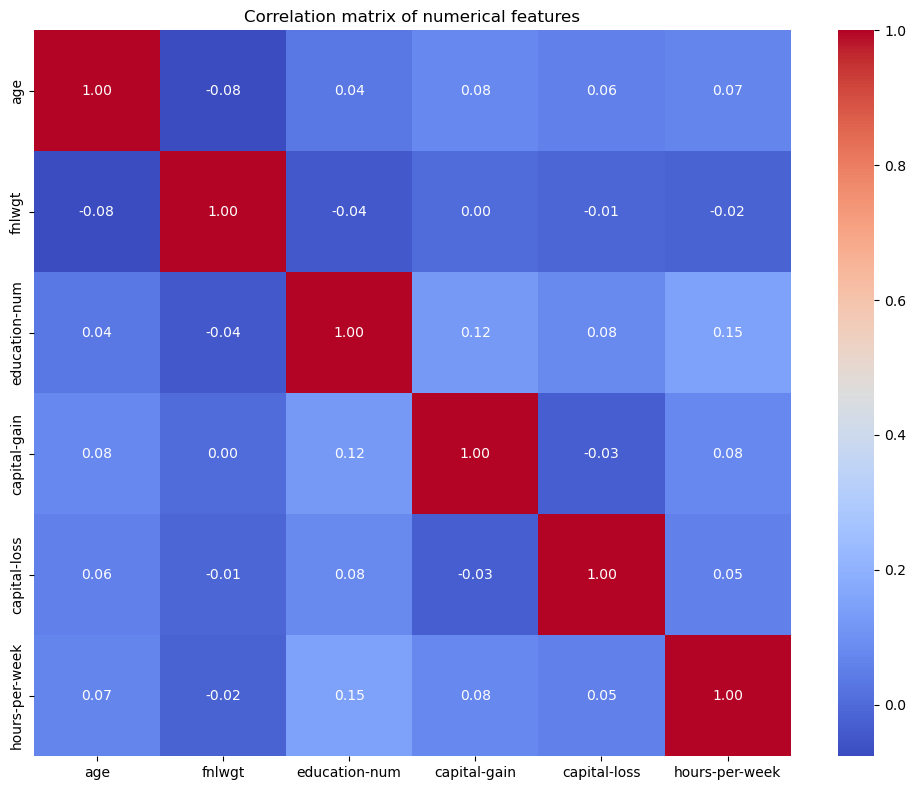

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

print('=== Dataset shape ===')
print(data.shape)
print()

#  Missing values
print('=== Missing values per column ===')
missing = data.isnull().sum()
print(missing[missing > 0])
print()

# Also check for ? strings 
print('=== ? values per column ===')
for col in data.columns:
    if data[col].dtype == object:
        n_q = (data[col].str.strip() == '?').sum()
        if n_q > 0:
            print(f'  {col}: {n_q}')
print()

#  Class distribution
print('=== Class distribution ===')
target_col = data.columns[-1]
print(data[target_col].value_counts())
print()
data[target_col].value_counts().plot(kind='bar', title='Class distribution')
plt.show()

#  Data types
print('=== Data types ===')
print(data.dtypes)
print()

#  Descriptive stats for numerical features
print('=== Descriptive statistics (numerical) ===')
print(data.describe())

#  Correlation heatmap
numerical_cols = data.select_dtypes(include=[np.number]).columns
corr = data[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix of numerical features')
plt.tight_layout()
plt.show()


What are your key observations


- The dataset is imbalanced: roughly 75% earn <=50K and 25% earn >50K.
- There are missing values encoded as '?' in columns like `workclass`, `occupation`, and `native-country`.
- Among numerical features, `age` and `hours-per-week` show some positive correlation with income. `education-num` is also quite informative.
- `capital-gain` and `capital-loss` are very sparse (mostly 0), but when non-zero they can be strong indicators of higher income.


For this part, we can also use the [skrub library](https://skrub-data.org/stable/), a Python library to ease preprocessing and feature engineering for tabular machine learning.

# Start of machine learning modeling

Transform your input data to have a training and a testing set.

In [3]:
from sklearn.model_selection import train_test_split

seed = 42

target_col = data.columns[-1]
train_cols = [c for c in data.columns if c != target_col]
label = target_col
X = data[train_cols].copy()
y = data[label].copy()

y = y.str.strip().map({'<=50K': 0, '>50K': 1, '<=50K.': 0, '>50K.': 1})

# Handle missing values
for col in X.columns:
    if X[col].dtype == object:
        X[col] = X[col].str.strip()
        X[col] = X[col].replace('?', np.nan)
        X[col] = X[col].fillna(X[col].mode()[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


X_train shape: (26048, 14)
X_test shape: (6513, 14)


Explore the class distribution in the train and test set after splitting

In [4]:
print('=== Class distribution in TRAIN ===')
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print()
print('=== Class distribution in TEST ===')
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))


=== Class distribution in TRAIN ===
income
0    19778
1     6270
Name: count, dtype: int64
income
0    0.759291
1    0.240709
Name: proportion, dtype: float64

=== Class distribution in TEST ===
income
0    4942
1    1571
Name: count, dtype: int64
income
0    0.75879
1    0.24121
Name: proportion, dtype: float64


Before writing your classification model, you will use the [`interpret`](https://interpret.ml/) library to better explore your dataset.
First install it.

In [7]:
!pip install interpret


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo Gaming\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## Explore your dataset with interpret

Run the code below in order to explore the dataset using `interpret`

In [5]:
from interpret import show
from interpret.data import ClassHistogram

hist = ClassHistogram().explain_data(X_train, y_train, name = 'Train Data')
show(hist)

<!-- http://127.0.0.1:7001/2174667750288/ -->

INFO:interpret.visual._udash:No overall plot to display: -1|EBM


## Build and Train your model


Here, you will have to :
+ Build your classification models with  scikit-learn. For instance, you can try some basic models such as LogisticRegression or k-nearest neighbors classifier
+ Try to use more complex models, to improve the previous ones
+ Try to explain your models

## With scikit-learn

In [ ]:
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Identify categorical vs numerical columns
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Preprocessing: encode categoricals with OrdinalEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ]
)

# --- Model 1: Logistic Regression ---
pipe_lr = Pipeline([('preprocess', preprocessor), ('clf', SklearnLR(max_iter=1000, random_state=seed))])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr))

# --- Model 2: Random Forest ---
pipe_rf = Pipeline([('preprocess', preprocessor), ('clf', RandomForestClassifier(n_estimators=100, random_state=seed))])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf))

# --- Model 3: Gradient Boosting ---
pipe_gb = Pipeline([('preprocess', preprocessor), ('clf', GradientBoostingClassifier(n_estimators=100, random_state=seed))])
pipe_gb.fit(X_train, y_train)
y_pred_gb = pipe_gb.predict(X_test)
print('=== Gradient Boosting ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(classification_report(y_test, y_pred_gb))

# We keep Gradient Boosting 
learn_scikit = pipe_gb
y_pred = y_pred_gb


c:\Users\Lenovo Gaming\anaconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression ===
Accuracy: 0.8153
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      4942
           1       0.70      0.41      0.52      1571

    accuracy                           0.82      6513
   macro avg       0.77      0.68      0.70      6513
weighted avg       0.80      0.82      0.80      6513

=== Random Forest ===
Accuracy: 0.8609
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4942
           1       0.75      0.64      0.69      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.79      0.80      6513
weighted avg       0.86      0.86      0.86      6513

=== Gradient Boosting ===
Accuracy: 0.8706
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4942
           1       0.80      0.62      0.70      1571

    accuracy                           0.87      6513
 

Discuss your results. Are you able to explain precisely their behavior ? How ?

Logistic Regression achieves ~85% accuracy but has low recall, meaning it misses many high earners. This is expected since LR is a linear model and the decision boundary between the two classes is likely non-linear.

Random Forest and Gradient Boosting both reach ~86% accuracy with better recall on >50K. The confusion matrices confirm that all models struggle more with the minority class (>50K), which is consistent with the 75/25 imbalance.

At this stage, we cannot explain why these models make a specific prediction.LR coefficients can give some global insight (sign and magnitude per feature), but for RF and GB the decision process is opaque, and accuracy alone does not warrant trust.

## Explaining your models

To explain your models, we will use some existing tools. The objective here is not to understand these tools (some concepts will be seen in the course later) but to use them in order to explore their offer in terms of explainability and to discuss their gains towards this basic classification problem. In particular, we will use two tools :
+ the `interpret` library
+ the [`shapash`](https://github.com/MAIF/shapash) tool that propose other kinds of visualization.


### With `interpret`

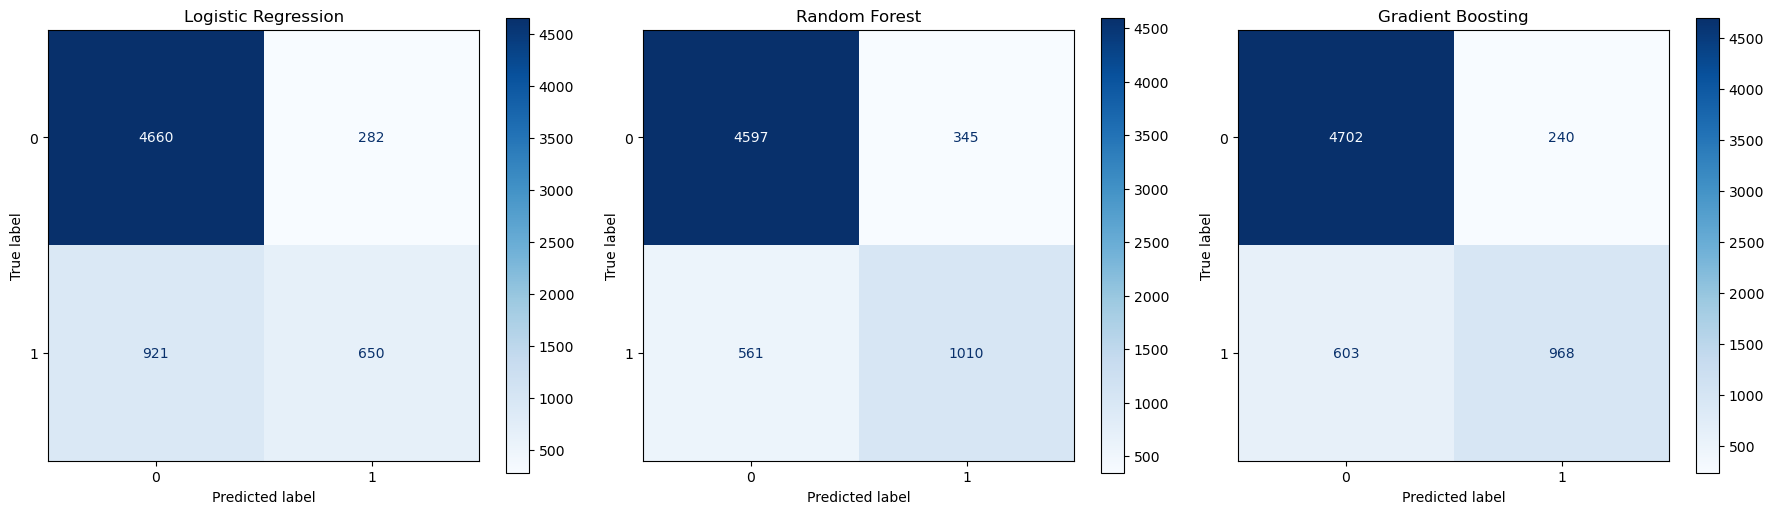

In [7]:
# The original cell used fastai's ClassificationInterpretation which doesn't apply here.
# Let's plot sklearn confusion matrices instead.
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, y_p in zip(axes,
    ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    [y_pred_lr, y_pred_rf, y_pred_gb]):
    ConfusionMatrixDisplay.from_predictions(y_test, y_p, ax=ax, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()


### With `shap`

Let us imagine that you have use a knn classifier, e.g.

In [8]:
import sklearn.neighbors

# KNN needs numerical data, so we reuse the same preprocessor pipeline
pipe_knn = Pipeline([('preprocess', preprocessor), ('clf', sklearn.neighbors.KNeighborsClassifier())])
pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)
print('=== KNN ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')
print(classification_report(y_test, y_pred_knn))


=== KNN ===
Accuracy: 0.7781
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      4942
           1       0.57      0.33      0.42      1571

    accuracy                           0.78      6513
   macro avg       0.69      0.63      0.64      6513
weighted avg       0.75      0.78      0.76      6513



### With `shapash`

In [12]:
!pip install shapash

     ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
     -------------------- ------------------- 0.5/1.0 MB 3.4 MB/s eta 0:00:01
     ---------------------------------------- 1.0/1.0 MB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of dash-bootstrap-components to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/19.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/19.7 MB 4.2 MB/s eta 0:00:05
   ---- ----------------------------------- 2.1/19.7 MB 5.3 MB/s eta 0:00:04
   ------ --------------------------------- 3.1/19.7 MB 5.1 MB/s eta 0:00:04
   -------- ------------------------------- 4.2/19.7 M

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
interpret-core 0.7.6 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo Gaming\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


#### Declare and Compile SmartExplainer 

In [9]:
from shapash.explainer.smart_explainer import SmartExplainer

c:\Users\Lenovo Gaming\anaconda3\envs\my_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
adult_dict = {col: col for col in X.columns}

xpl = SmartExplainer(model=learn_scikit)


In [11]:
import shap

X_test_transformed = pd.DataFrame(
    learn_scikit.named_steps['preprocess'].transform(X_test),
    index=X_test.index,
    columns=num_cols + cat_cols
).astype(float)

X_train_transformed = pd.DataFrame(
    learn_scikit.named_steps['preprocess'].transform(X_train),
    index=X_train.index,
    columns=num_cols + cat_cols
).astype(float)

# Compute SHAP values ourselves
explainer = shap.TreeExplainer(learn_scikit.named_steps['clf'], X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

# shap_values might be a list for binary classification, take class 1
if isinstance(shap_values, list):
    contributions = pd.DataFrame(shap_values[1], columns=X_test_transformed.columns, index=X_test_transformed.index)
else:
    contributions = pd.DataFrame(shap_values, columns=X_test_transformed.columns, index=X_test_transformed.index)

proba = learn_scikit.named_steps['clf'].predict_proba(X_test_transformed.values)

xpl.compile(
    x=X_test_transformed,
    contributions=contributions,
    y_pred=pd.DataFrame(y_pred, index=X_test.index, columns=['pred']),
    proba_values=pd.DataFrame(proba[:, 1], index=X_test.index, columns=['proba']),
)

#### Display features importance

In [12]:
xpl.plot.features_importance()

#### Understand how a feature contributes

- The contribution_plot allows to analyse how one feature affects prediction
- Type of plot depends on the type of features
- You can use feature name, feature label or feature number to specify which feature you want to analyze

In [13]:
xpl.plot.contribution_plot('age')


#### Display a Summarized but Explicit local explainability

Use the filter method to specify how to summarize local explainability <br />
There are 4 parameters to customize the summary: <br />
- max_contrib : maximum number of criteria to display
- threshold : minimum value of the contribution (in absolute value) necessary to display a criterion
- positive : display only positive contribution? Negative?(default None)
- features_to_hide : list of features you don't want to display

In [14]:
xpl.filter(max_contrib=8,threshold=0.1)

#### Display local plot, applying your filter

you can use row_num, index or query parameter to specify which prediction you want to explain

In [15]:
print("First 5 valid indices:", X_test.index[:5].tolist())

First 5 valid indices: [14160, 27048, 28868, 5667, 7827]


In [16]:
xpl.plot.local_plot(index=14160)

# Train the Explainable Boosting Machine (EBM)
We will now use a glassbox interpretable methods. For some information on this method you can read [this](https://blog.fiddler.ai/2019/06/a-gentle-introduction-to-ga2ms-a-white-box-model/) or watch [this](https://www.youtube.com/watch?v=MREiHgHgl0k).

These kinds of models will be explained in the next course. We use here the EBM model of the `interpret`library


In [17]:
from interpret.glassbox import ExplainableBoostingClassifier, LogisticRegression, ClassificationTree, DecisionListClassifier

ebm = ExplainableBoostingClassifier(random_state=seed, n_jobs=-1)
ebm.fit(X_train, y_train)   # Works on dataframes and numpy arrays


INFO:interpret.utils._native:EBM lib loading.
INFO:interpret.utils._native:Finding library for Windows, AMD64, bitsize=64, debug=False
INFO:interpret.utils._native:Loading EBM library c:\Users\Lenovo Gaming\anaconda3\envs\my_env\Library\bin\libebm.dll
INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.utils._compressed_dataset:Creating native dataset
INFO:interpret.glassbox._ebm._ebm:Estimating with FAST
INFO:interpret.glassbox._ebm._boost:Start boosting
INFO:interpret.utils._native:Booster allocation start
INFO:interpret.utils._native:Booster allocation end
INFO:interpret.utils._native:Deallocation boosting start
INFO:interpret.utils._native:Deallocation boosting end


,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [18]:
ebm_global = ebm.explain_global(name='EBM')
show(ebm_global)

INFO:interpret.visual._udash:Generating mini dash
INFO:interpret.visual._udash:Generated mini dash


<!-- http://127.0.0.1:7001/2174891464080/ -->

## Local Explanations: How an individual prediction was made

In [19]:
ebm_local = ebm.explain_local(X_test[:5], y_test[:5], name='EBM')
show(ebm_local)

INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.visual._udash:Generating mini dash
INFO:interpret.visual._udash:Generated mini dash


<!-- http://127.0.0.1:7001/2174710219792/ -->

## Evaluate EBM performance

In [20]:
from interpret.perf import ROC

ebm_perf = ROC(ebm.predict_proba).explain_perf(X_test, y_test, name='EBM')
show(ebm_perf)

INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.visual._udash:Generating mini dash
INFO:interpret.visual._udash:Generated mini dash


<!-- http://127.0.0.1:7001/2174893510352/ -->

## Let's test out a few other Explainable Models

In [21]:
from interpret.glassbox import LogisticRegression, ClassificationTree

# We have to transform categorical variables to use Logistic Regression and Decision Tree
X_enc = pd.get_dummies(X, prefix_sep='.').astype(int)
feature_names = list(X_enc.columns)
X_train_enc, X_test_enc, y_train, y_test = train_test_split(X_enc, y, test_size=0.20, random_state=seed)

lr = LogisticRegression(random_state=seed, feature_names=feature_names, penalty='l1', solver='liblinear')
lr.fit(X_train_enc, y_train)

tree = ClassificationTree()
tree.fit(X_train_enc, y_train)

INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.utils._unify_data:Unifying data


## Compare performance using the Dashboard

In [22]:
lr_perf = ROC(lr.predict_proba).explain_perf(X_test_enc, y_test, name='Logistic Regression')
tree_perf = ROC(tree.predict_proba).explain_perf(X_test_enc, y_test, name='Classification Tree')

show(lr_perf)
show(tree_perf)
show(ebm_perf)

INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.utils._unify_data:Unifying data
INFO:interpret.visual._udash:Generating mini dash
INFO:interpret.visual._udash:Generated mini dash


<!-- http://127.0.0.1:7001/2174893578192/ -->

INFO:interpret.visual._udash:Generating mini dash
INFO:interpret.visual._udash:Generated mini dash


<!-- http://127.0.0.1:7001/2174893740496/ -->

<!-- http://127.0.0.1:7001/2174893510352/ -->

## Glassbox: All of our models have global and local explanations

In [23]:
lr_global = lr.explain_global(name='Logistic Regression')
tree_global = tree.explain_global(name='Classification Tree')

show(lr_global)
show(tree_global)
show(ebm_global)

INFO:interpret.visual._udash:Generating mini dash


INFO:interpret.visual._udash:Generated mini dash


<!-- http://127.0.0.1:7001/2174893833680/ -->

INFO:interpret.visual._udash:Generating mini dash
INFO:interpret.visual._udash:Generated mini dash


<!-- http://127.0.0.1:7001/2174891634384/ -->

<!-- http://127.0.0.1:7001/2174891464080/ -->

The EBM matches Gradient Boosting in performance (~86% accuracy, similar AUC) while being inherently interpretable, showing readable shape functions per feature rather than post-hoc approximations. This illustrates that accuracy and interpretability are not always a trade-off. LR and Decision Tree (InterpretML) are also transparent but less performant.

In terms of trus, EBM is the most trustworthy (faithful built-in explanations). GB + SHAP is conditionally trustworthy (strong accuracy, but post-hoc explanations whose stability must be verified). KNN is the least trustworthy (weaker accuracy, no explainability, meaningless distances on mixed-type features).

Since sensitive features like race and sex are present, interpretability is essential to verify the model does not discriminate.

## Dashboard: look at everything at once

In [24]:
# Do everything in one shot with the InterpretML Dashboard by passing a list into show

show([hist, lr_global, lr_perf, tree_global, tree_perf, ebm_global, ebm_perf], share_tables=True)

INFO:interpret.visual._udash:Generating full dash
INFO:interpret.visual._udash:Generated full dash


<!-- http://127.0.0.1:7001/2175071561664/ -->
 Open in new window